# BrainScanAI — Benchmarking of 4 models on brain tumors classification

**Objective :** comparative study of 4 models on the same task to measure:

1. **Precision** : how modern neural network architecture influence the classification
2. **Costs / Inference** : training (few data) entraînement (peu de données, peu de paramètres) and deployment (size, inference)

| Model | Techno | Year | Role |
|---|---|---|---|
| `microsoft/resnet-50` | CNN  | 2015 | Residual CNN - to solve vaniching gradients |
| `google/vit-base-patch16-224` | Vision Transformer | 2021 | attention mechanism instead of convolutions |
| `facebook/dinov2-base` | self supervised foundation model | 2023 | light training, generability |
| `microsoft/BiomedCLIP-...` | multimodal foundation model  | 2023 | reference in medicine |

**Evals :** linear-probe (frozen backbone + head training) with fine-tuning for the 3 models Hugging Face ; zero-shot and linear-probe for BiomedCLIP.

## Data:
Launch the kaggle_data_download.sh script to download the data in the data fodler of this repo. Images are split in 4 subfolders named after the tumor type in 2 parent folder named Training and Testing. 

In [1]:
import glob
import pandas as pd

In [12]:
# Creating atrain and tests df with all the image path
train_img_list = glob.glob('./data/Training/*/*.jpg')
train_img_list = list(map(lambda x : [x, x.split('/')[3]], train_img_list ))

test_img_list = glob.glob('./data/Testing/*/*.jpg')
test_img_list = list(map(lambda x : [x, x.split('/')[3]], test_img_list ))

# Creating a df out of the list of images path
df_train = pd.DataFrame(train_img_list, columns = ['filepath', 'nameLabel'])
df_test = pd.DataFrame(test_img_list, columns = ['filepath', 'nameLabel'])

# Create a mapping of class names to integer labels
mapping_classes = {"notumor" : 0, "glioma" : 1, "meningioma" : 2, "pituitary" : 3}

# Numerical encoding of tumor types
df_train['label'] = df_train['nameLabel'].map(mapping_classes)
df_test['label']  = df_test['nameLabel'].map(mapping_classes)


In [13]:
df_train.head()

,filepath,nameLabel,label
0,./data/Training/notumor/Tr-no_869.jpg,notumor,0
1,./data/Training/notumor/Tr-no_1152.jpg,notumor,0
2,./data/Training/notumor/Tr-no_737.jpg,notumor,0
3,./data/Training/notumor/Tr-no_413.jpg,notumor,0
4,./data/Training/notumor/Tr-no_903.jpg,notumor,0


/tmp/ipykernel_349/507114662.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'nameLabel', palette = 'Set2')


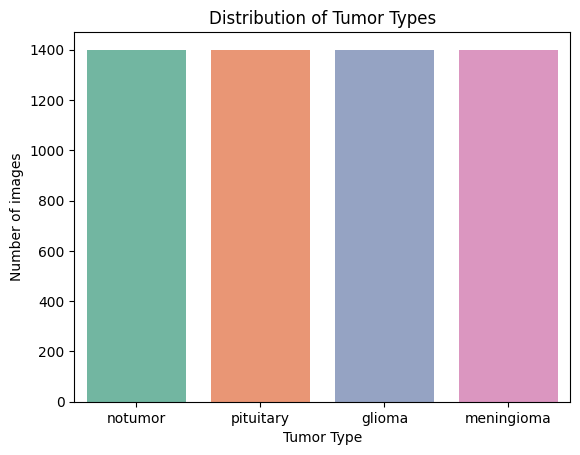

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Let's visualize the classes:
sns.countplot(data = df, x = 'nameLabel', palette = 'Set2')
plt.title('Distribution of Tumor Types')
plt.xlabel('Tumor Type')
plt.ylabel('Number of images')
plt.show()

In [4]:
print('Number of image per label:')
print(df['nameLabel'].value_counts())

Number of image per label:
nameLabel
notumor       1400
pituitary     1400
glioma        1400
meningioma    1400
Name: count, dtype: int64


Classes are balanced.

In [5]:
df.to_csv('img_path.csv', index = False)

In [6]:
from sklearn.model_selection import train_test_split

# Splitting the data into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    df['filepath'].values, 
    df['label'].values, 
    test_size=0.2, 
    random_state=123)

In [7]:
import torch
from PIL import Image

from transformers import AutoImageProcessor
from torch.utils.data import DataLoader

device = 'cuda'

processor = AutoImageProcessor.from_pretrained('WinKawaks/vit-small-patch16-224')

class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, device = device):
        self.X = X
        self.y = y
        self.device = device

    def __getitem__(self, idx):
        # Image processing specific to the model for training
        im = Image.open(self.X[idx]).convert('RGB')
        encoding = processor(im, return_tensors = 'pt')

        return {'pixel_values' : encoding["pixel_values"][0], 
                'labels' : torch.tensor(self.y[idx])}

    def __len__(self):
        return len(self.X)

dataset_train = CustomDataset(X_train, y_train, device)
dataloader_train = DataLoader(dataset_train, batch_size = 32, shuffle = True)

dataset_test = CustomDataset(X_test, y_test, device)
dataloader_test = DataLoader(dataset_test, batch_size=32, shuffle = False)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape X : torch.Size([32, 3, 224, 224])
Shape y : torch.Size([32])


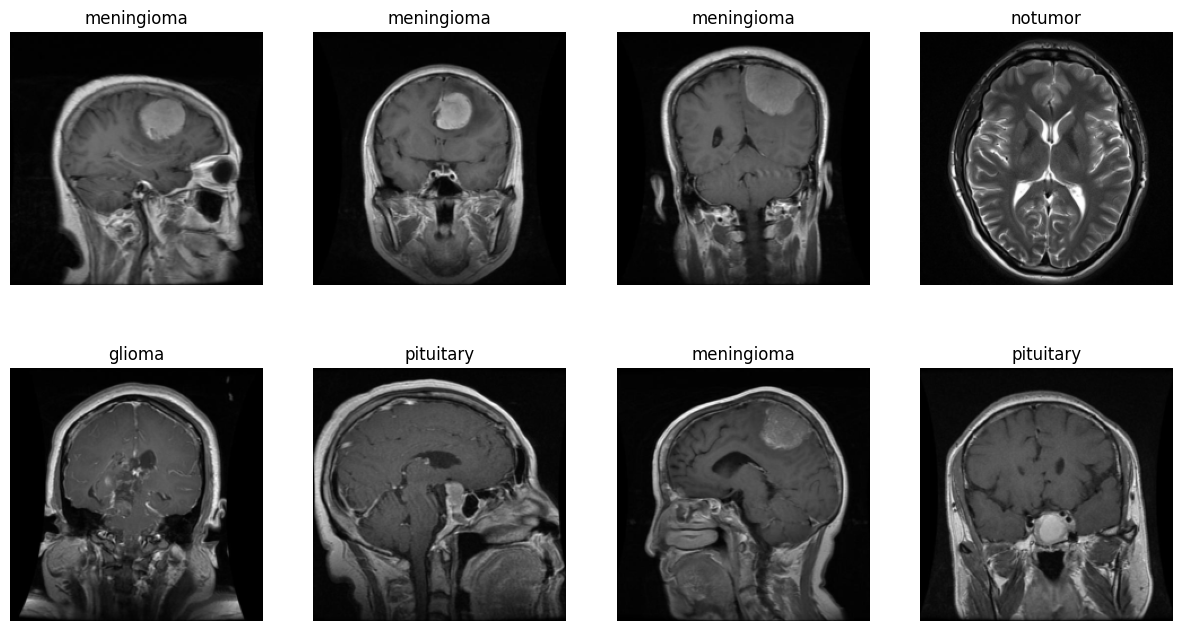

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

data = next(iter(dataloader_train))

X_t, y_t = data['pixel_values'], data['labels']
print(f"Shape X : {X_t.shape}")
print(f"Shape y : {y_t.shape}")
plt.figure(figsize=(15,8))
j=1
for i in np.random.randint(0, len(X_t), size=[8]):
    plt.subplot(2,4,j)
    plt.axis('off')
    im = X_t[i].permute(1, 2, 0)
    # Normalisation de l'image pour qu'elle soit entre 0 et 1
    plt.imshow((im.cpu() - im.cpu().min())/(im.cpu().max()- im.cpu().min()) )
    plt.title(df.nameLabel.unique()[y_t[i].item()])
    j+=1

In [12]:
from transformers import AutoModelForImageClassification

# We have 4 classes of tumor types
nb_class: int = 4

# Running the model on GPU 
device: str = "cuda"

model = AutoModelForImageClassification.from_pretrained('WinKawaks/vit-small-patch16-224', 
                                                        num_labels = nb_class,
                                                        ignore_mismatched_sizes = True)

model.to(device)

print(model)

You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 24893.49it/s]
ViTForImageClassification LOAD REPORT from: WinKawaks/vit-small-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([4])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 384]) vs model:torch.Size([4, 384])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=384, out_features=1536, bias=True)
            (intermed

In [13]:
X_t = next(iter(dataloader_train))

X_t['pixel_values'] = X_t['pixel_values'].to(device)
X_t['labels'] = X_t['labels'].to(device)
model(**X_t)

ImageClassifierOutput(loss=tensor(1.7945, device='cuda:0', grad_fn=<NllLossBackward0>), logits=tensor([[ 3.8169e-01, -1.4297e+00,  5.0922e-01, -3.0578e-01],
        [ 3.7164e-01, -1.9581e+00,  5.5479e-01,  3.7159e-01],
        [ 6.2400e-01, -2.1204e+00,  4.9563e-01, -7.5568e-02],
        [ 7.0462e-01, -2.7845e+00,  7.3028e-01,  1.7879e-01],
        [ 6.0068e-01, -3.1753e+00,  5.9854e-01,  2.3138e-01],
        [ 3.4991e-01, -2.3726e+00,  8.2128e-01,  6.6324e-01],
        [ 2.8460e-01, -1.9578e+00,  4.3534e-02,  1.5057e-01],
        [ 4.6845e-01, -3.2116e+00,  2.9196e-01,  4.6670e-02],
        [ 4.6079e-01, -2.3337e+00,  1.5279e+00,  3.3920e-01],
        [ 8.1962e-01, -2.3442e+00,  6.4903e-01, -8.6930e-01],
        [ 4.5426e-01, -2.2097e+00,  4.3665e-01, -3.2023e-02],
        [ 2.3295e-02, -2.1074e+00,  5.2976e-01, -3.9619e-01],
        [-6.0188e-01, -1.6409e+00,  3.9975e-01, -1.9456e-02],
        [ 6.3843e-01, -1.8458e+00, -1.3013e-01,  4.9587e-01],
        [ 6.2989e-01, -1.7728e+00,  3

In [14]:
# training using the Trainer API from HuggingFace
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir = './models/checkpoints',
    num_train_epochs = 10,
    logging_dir = './models/logs',
    logging_steps = 50,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    learning_rate = 1e-4,
    eval_strategy = 'epoch',
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [15]:
import evaluate
import numpy as np

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [16]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = dataset_train,
    eval_dataset = dataset_test,
    compute_metrics = compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.146395,0.162250,0.948214
2,0.081749,0.104953,0.966964
3,0.015465,0.097112,0.978571
4,0.001009,0.075575,0.982143
5,0.005433,0.111997,0.977679
6,0.000105,0.105553,0.983929
7,0.000012,0.101363,0.983036
8,0.000010,0.100064,0.983929
9,0.000009,0.099714,0.983929
10,0.000008,0.099691,0.983929


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 24.06it/s]


TrainOutput(global_step=1400, training_loss=0.034956938231314, metrics={'train_runtime': 142.3957, 'train_samples_per_second': 314.616, 'train_steps_per_second': 9.832, 'total_flos': 8.766968135417856e+17, 'train_loss': 0.034956938231314, 'epoch': 10.0})

In [17]:
model.save_pretrained('./models/final_model')


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 18.10it/s]


Text(0.5, 1.0, 'Importance class meningioma')

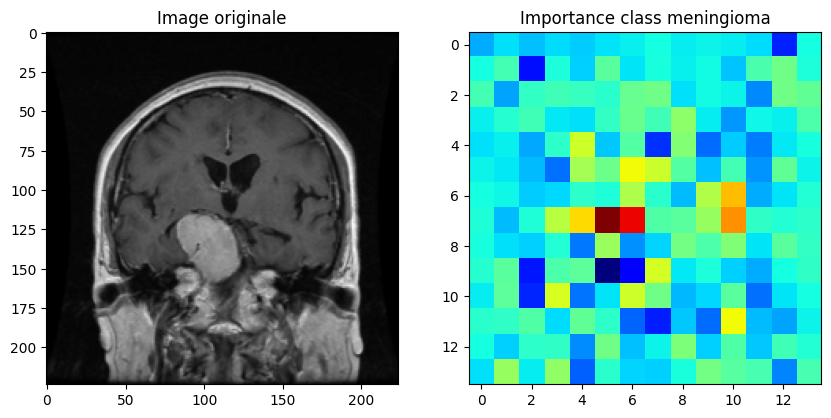

In [ ]:
from captum.attr import LayerIntegratedGradients
import torch
import numpy as np

def model_output(inputs):
    return model(inputs)[0]


lig = LayerIntegratedGradients(model_output, model.vit.embeddings.patch_embeddings.projection)


device = "cuda"

def show_importance(model, input_tensor, target=0, device=device):
    input_tensor = input_tensor.to(device)
    model.to(device)
    # Compute the importance score for each input values.
    attributions, delta = lig.attribute(inputs=input_tensor, target=target,
                                    return_convergence_delta=True, n_steps=100)
    
    # Transform the importance score to importance of each token.
    importance = attributions.sum(dim=1).squeeze(0)
    importance = importance / torch.norm(importance)
    importance = importance.cpu().detach().numpy()
    # Une autre normalisation possible (similaire à celle du grad-cam)
#     importance = np.maximum(importance, 0)  # Ne garder que les valeurs positives
#     importance /= np.max(importance)  # Normaliser la heatmap
    return importance


data = next(iter(dataloader_test))
i = np.random.randint(0, len(data['pixel_values']))
img_tensor = data['pixel_values'][i]
target = data['labels'][i].item()


heatmap = show_importance(model, img_tensor.unsqueeze(0), target)


plt.figure(figsize=(10, 7))

# Show the original image
plt.subplot(1, 2, 1)
plt.imshow(((img_tensor - img_tensor.min())/(img_tensor.max()-img_tensor.min())).permute(1,2,0).cpu())
plt.title("Image originale")

# Show the heatmap for the tumor region
plt.subplot(1, 2, 2)
plt.imshow(heatmap, cmap='jet')
plt.title(f"Importance class {df.nameLabel.unique()[target]}")


Text(0.5, 1.0, 'Importance class notumor')

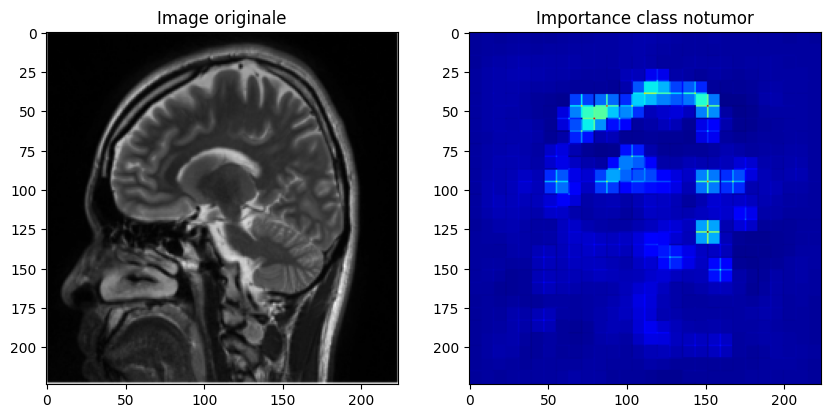

In [ ]:
from captum.attr import Occlusion
import torch
import numpy as np

def model_output(inputs):
    return model(inputs)[0]



lig = Occlusion(model_output)


device = "cuda"

def show_importance(model, input_tensor, target=0, device=device):
    input_tensor = input_tensor.to(device)
    model.to(device)
    # Compute the importance score for each input values.
    attributions = lig.attribute(inputs=input_tensor, strides = (3, 8, 8), target=target, sliding_window_shapes=(3, 15, 15) )
    
    
    # Transform the importance score to importance of each token.
    importance = attributions.sum(dim=1).squeeze(0)
    importance = importance / torch.norm(importance)
    importance = importance.cpu().detach().numpy()
    # Normalisaiton GradCam
#     importance = np.maximum(importance, 0)  # Ne garder que les valeurs positives
#     importance /= np.max(importance)  # Normaliser la heatmap
    return importance


data = next(iter(dataloader_test))
i = np.random.randint(0, len(data['pixel_values']))
img_tensor = data['pixel_values'][i]
target = data['labels'][i].item()


heatmap = show_importance(model, img_tensor.unsqueeze(0), target)

plt.figure(figsize=(10, 7))

# Show the original image
plt.subplot(1, 2, 1)
plt.imshow(((img_tensor - img_tensor.min())/(img_tensor.max()-img_tensor.min())).permute(1,2,0).cpu())
plt.title("Image originale")

# Show the heatmap for the tumor region
plt.subplot(1, 2, 2)
plt.imshow(heatmap, cmap='jet')
plt.title(f"Importance class {df.nameLabel.unique()[target]}")


# Model evaluation

In [ ]:
# Creating a df with all the image path
img_list = glob.glob('./data/Testing/*/*.jpg')
img_list = list(map(lambda x : [x, x.split('/')[3]], img_list ))

# Creating a df out of the list of images path
df_test = pd.DataFrame(img_list, columns = ['filepath', 'nameLabel'])

# Numerical encoding of tumor types
df['label'] = df['nameLabel'].replace(df.nameLabel.unique(), [*range(len(df.nameLabel.unique()))])
df.head()